In [1]:
# Cell 1 — Imports + config
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ---- paths ----
DATA_ROOT = Path("./v18")
SPLIT = "train"  # "train" or "val"

IMG_DIR = DATA_ROOT / SPLIT
ANN_PATH = IMG_DIR / "annotations.json"  # optional (used to list stems)

DINO_NAME = "dinov2_vits14"
K_REGIONS = 5

CLUSTER_MAPS_DIR = DATA_ROOT / "dino_global_clusters" / f"maps_{DINO_NAME}_k{K_REGIONS}"
assert CLUSTER_MAPS_DIR.exists(), f"Missing cluster maps dir: {CLUSTER_MAPS_DIR}"

# ---- dataloader ----
BATCH_SIZE = 128
NUM_WORKERS = 4

# ---- image preprocessing (optional, NOT needed for histograms) ----
LOAD_IMAGES = True          # if False, only loads clusters
TARGET_SIZE = 256           # only used if LOAD_IMAGES=True and you want resize+pad
NORMALIZE_MINUS1_1 = False  # only used if LOAD_IMAGES=True

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("IMG_DIR:", IMG_DIR)
print("CLUSTER_MAPS_DIR:", CLUSTER_MAPS_DIR)


device: cuda
IMG_DIR: v18/train
CLUSTER_MAPS_DIR: v18/dino_global_clusters/maps_dinov2_vits14_k5


In [5]:
# Cell 2 — Helpers: stems listing
def stems_from_annotations(ann_path: Path) -> List[str]:
    ann = json.loads(ann_path.read_text())
    stems: List[str] = []
    for img in ann.get("images", []):
        fn = img.get("file_name", "")
        stems.append(Path(fn).stem)
    return stems

def stems_from_dir(img_dir: Path) -> List[str]:
    stems: List[str] = []
    for p in sorted(img_dir.glob("*.npy")):
        # avoid accidentally picking cluster npys if they are in the same folder (usually they aren't)
        if p.name.endswith("_clusters.npy"):
            continue
        stems.append(p.stem)
    return stems

if ANN_PATH.exists():
    stems = stems_from_annotations(ANN_PATH)
    print("stems from annotations:", len(stems))
else:
    stems = stems_from_dir(IMG_DIR)
    print("stems from directory:", len(stems))


stems from annotations: 6725


In [6]:
# Cell 3 — Helpers: image loading (optional)
def load_npy_as_tensor_1hw(path: Path) -> torch.Tensor:
    x = np.load(path)
    if x.ndim == 2:
        x = x[None, ...]
    elif x.ndim == 3 and x.shape[0] != 1:
        x = x[:1, ...]
    return torch.from_numpy(x).float()  # (1,H,W)

def resize_pad_to_square(x_1hw: torch.Tensor, target: int = 256) -> torch.Tensor:
    _, h, w = x_1hw.shape
    scale = target / max(h, w)
    nh, nw = int(round(h * scale)), int(round(w * scale))

    x = F.interpolate(
        x_1hw.unsqueeze(0),
        size=(nh, nw),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    pad_h = target - nh
    pad_w = target - nw
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left

    pad_val = float(x.min().item())
    x = F.pad(x, (left, right, top, bottom), mode="constant", value=pad_val)
    return x  # (1,target,target)

def normalize_to_minus1_1(x_1hw: torch.Tensor) -> torch.Tensor:
    x = x_1hw
    x = x - x.amin(dim=(1, 2), keepdim=True)
    x = x / (x.amax(dim=(1, 2), keepdim=True) + 1e-8)
    return 2 * x - 1


In [7]:
# Cell 4 — Dataset: loads cluster maps (+ images optionally)
class ImageClusterDataset(Dataset):
    def __init__(
        self,
        img_dir: Path,
        cluster_maps_dir: Path,
        stems: List[str],
        k_regions: int,
        load_images: bool = True,
        target_size: Optional[int] = None,
        normalize_minus1_1: bool = False,
        drop_missing: bool = True,
    ):
        self.img_dir = img_dir
        self.cluster_maps_dir = cluster_maps_dir
        self.k_regions = k_regions
        self.load_images = load_images
        self.target_size = target_size
        self.normalize_minus1_1 = normalize_minus1_1

        usable: List[str] = []
        missing = 0
        for stem in stems:
            cmap_ok = (cluster_maps_dir / f"{stem}_clusters.npy").exists()
            img_ok = (img_dir / f"{stem}.npy").exists() if load_images else True

            if cmap_ok and img_ok:
                usable.append(stem)
            else:
                missing += 1
                if not drop_missing:
                    usable.append(stem)

        if len(usable) == 0:
            raise RuntimeError("No usable items found. Check stems / file presence.")
        self.stems = usable
        self.missing = missing

    def __len__(self) -> int:
        return len(self.stems)

    def __getitem__(self, idx: int) -> Dict:
        stem = self.stems[idx]

        # cluster map
        cmap_path = self.cluster_maps_dir / f"{stem}_clusters.npy"
        lbl = np.load(cmap_path).astype(np.int64)  # (Gh,Gw)
        lbl_t = torch.from_numpy(lbl)  # int64

        out = {"cluster_lbl": lbl_t, "stem": stem}

        # optional image
        if self.load_images:
            img_path = self.img_dir / f"{stem}.npy"
            x = load_npy_as_tensor_1hw(img_path)
            if self.target_size is not None:
                x = resize_pad_to_square(x, target=self.target_size)
            if self.normalize_minus1_1:
                x = normalize_to_minus1_1(x)
            out["image"] = x  # (1,H,W) or (1,target,target)

        return out

ds = ImageClusterDataset(
    img_dir=IMG_DIR,
    cluster_maps_dir=CLUSTER_MAPS_DIR,
    stems=stems,
    k_regions=K_REGIONS,
    load_images=LOAD_IMAGES,
    target_size=TARGET_SIZE if LOAD_IMAGES else None,
    normalize_minus1_1=NORMALIZE_MINUS1_1,
    drop_missing=True,
)

print("usable items:", len(ds))
print("missing filtered out:", ds.missing)
print("example keys:", ds[0].keys())
print("example cluster shape:", ds[0]["cluster_lbl"].shape)


usable items: 6725
missing filtered out: 0
example keys: dict_keys(['cluster_lbl', 'stem', 'image'])
example cluster shape: torch.Size([16, 16])


In [8]:
# Cell 5 — DataLoader
def collate_keep_stems(batch: List[Dict]) -> Dict:
    # cluster_lbl -> stack
    cluster_lbl = torch.stack([b["cluster_lbl"] for b in batch], dim=0)  # (B,Gh,Gw)
    stems = [b["stem"] for b in batch]
    out = {"cluster_lbl": cluster_lbl, "stem": stems}

    if "image" in batch[0]:
        images = torch.stack([b["image"] for b in batch], dim=0)  # (B,1,H,W)
        out["image"] = images

    return out

loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_keep_stems,
)

batch = next(iter(loader))
print("batch cluster_lbl:", batch["cluster_lbl"].shape)
print("batch stems:", len(batch["stem"]))
if "image" in batch:
    print("batch image:", batch["image"].shape)


batch cluster_lbl: torch.Size([128, 16, 16])
batch stems: 128
batch image: torch.Size([128, 1, 256, 256])


In [9]:
# Cell 6 — Histogram utils
def _fix_label_range(lbl: torch.Tensor, k: int) -> torch.Tensor:
    """
    Ensure labels are in [0..k-1].
    If labels look like [1..k], shift by -1.
    Then clamp for safety.
    """
    lbl_min = int(lbl.min().item())
    lbl_max = int(lbl.max().item())

    if lbl_min == 1 and lbl_max == k:
        lbl = lbl - 1

    # If labels are outside range, clamp (or replace with assert if you prefer strict)
    lbl = torch.clamp(lbl, 0, k - 1)
    return lbl

def counts_to_probs(counts: np.ndarray) -> np.ndarray:
    s = int(counts.sum())
    return counts.astype(np.float64) / (s + 1e-12)

@torch.no_grad()
def compute_histograms(loader: DataLoader, k_regions: int):
    """
    Returns:
      per_image_counts: dict stem -> (k,) int64
      per_image_probs:  dict stem -> (k,) float64
      global_counts: (k,) int64
      global_probs:  (k,) float64
    """
    per_image_counts: Dict[str, np.ndarray] = {}
    global_counts = np.zeros((k_regions,), dtype=np.int64)

    for batch in tqdm(loader, desc="Computing histograms"):
        lbl = batch["cluster_lbl"]          # (B,Gh,Gw) int64
        stems = batch["stem"]              # list[str]
        B = lbl.shape[0]

        lbl = _fix_label_range(lbl, k_regions)
        flat = lbl.view(B, -1)

        for i in range(B):
            c = torch.bincount(flat[i], minlength=k_regions).cpu().numpy().astype(np.int64)
            per_image_counts[stems[i]] = c
            global_counts += c

    per_image_probs = {k: counts_to_probs(v) for k, v in per_image_counts.items()}
    global_probs = counts_to_probs(global_counts)

    return per_image_counts, per_image_probs, global_counts, global_probs


In [10]:
# Cell 7 — Run histogram computation
per_counts, per_probs, global_counts, global_probs = compute_histograms(loader, K_REGIONS)

print("num per-image stats:", len(per_counts))
print("global counts:", global_counts)
print("global probs :", np.round(global_probs, 4))


Computing histograms: 100%|██████████| 53/53 [00:02<00:00, 18.40it/s]

num per-image stats: 6725
global counts: [434584 468534 295907 172041 350534]
global probs : [0.2524 0.2722 0.1719 0.0999 0.2036]


In [11]:
# Cell 8 — Quick sanity checks + summary stats
# 1) ensure sums match total patches
# cluster map grid size (Gh*Gw) inferred from first example
Gh, Gw = ds[0]["cluster_lbl"].shape
patches_per_img = Gh * Gw

total_imgs = len(ds)
expected_total = total_imgs * patches_per_img
actual_total = int(global_counts.sum())

print("cluster grid:", (Gh, Gw), "patches/img:", patches_per_img)
print("expected total patches:", expected_total)
print("actual total patches  :", actual_total)

# 2) min/max frequency clusters
freq = global_probs
print("rarest cluster:", int(np.argmin(freq)), "freq:", float(freq.min()))
print("most common  :", int(np.argmax(freq)), "freq:", float(freq.max()))

# 3) average entropy of per-image distributions (optional)
def entropy(p: np.ndarray) -> float:
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p * np.log(p)).sum())

ents = np.array([entropy(p) for p in per_probs.values()], dtype=np.float64)
print("per-image entropy: mean", float(ents.mean()), "std", float(ents.std()), "min", float(ents.min()), "max", float(ents.max()))


cluster grid: (16, 16) patches/img: 256
expected total patches: 1721600
actual total patches  : 1721600
rarest cluster: 3 freq: 0.09993087825278811
most common  : 1 freq: 0.2721503252788104
per-image entropy: mean 1.4608540865341797 std 0.08039681960346594 min 0.9437302013253562 max 1.5920460008833772


In [12]:
# Cell 9 — Save outputs (optional)
OUT_DIR = DATA_ROOT / "cluster_stats"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save global
np.save(OUT_DIR / f"{SPLIT}_global_counts_k{K_REGIONS}.npy", global_counts)
np.save(OUT_DIR / f"{SPLIT}_global_probs_k{K_REGIONS}.npy", global_probs)

# Save per-image (counts + probs) as npz
# (npz is faster/safer than json for big dicts)
np.savez_compressed(
    OUT_DIR / f"{SPLIT}_per_image_counts_probs_k{K_REGIONS}.npz",
    **{f"{stem}__counts": c for stem, c in per_counts.items()},
    **{f"{stem}__probs":  p for stem, p in per_probs.items()},
)

print("saved to:", OUT_DIR)


saved to: v18/cluster_stats


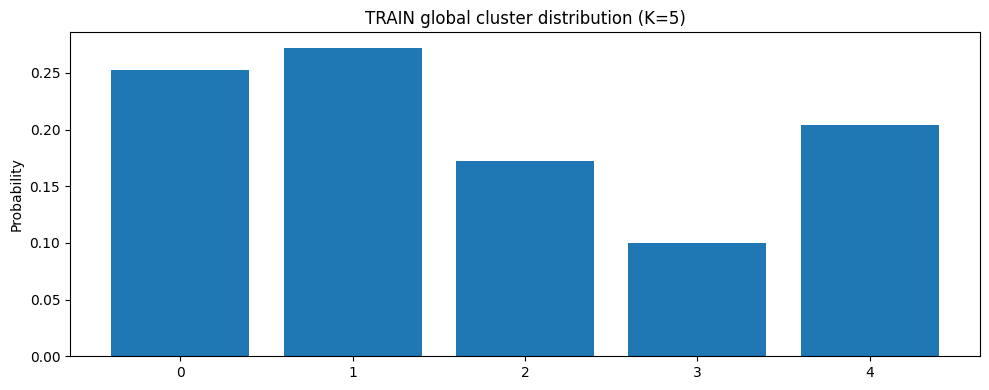

val_global_probs not found. Run Cell 10 to compute val stats.


In [13]:
# Cell 11 — Plot global histograms (train vs val if available)
import matplotlib.pyplot as plt
import numpy as np

def plot_bar(prob: np.ndarray, title: str):
    x = np.arange(len(prob))
    plt.figure(figsize=(10, 4))
    plt.bar(x, prob)
    plt.xticks(x)
    plt.ylabel("Probability")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_bar(global_probs, f"{SPLIT.upper()} global cluster distribution (K={K_REGIONS})")

# If you computed val_global_probs in Cell 10, plot it too + overlay comparison
try:
    _ = val_global_probs  # noqa
    plot_bar(val_global_probs, f"VAL global cluster distribution (K={K_REGIONS})")

    # side-by-side comparison
    x = np.arange(K_REGIONS)
    w = 0.4
    plt.figure(figsize=(10, 4))
    plt.bar(x - w/2, global_probs, width=w, label="train")
    plt.bar(x + w/2, val_global_probs, width=w, label="val")
    plt.xticks(x)
    plt.ylabel("Probability")
    plt.title(f"Train vs Val global cluster distribution (K={K_REGIONS})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # difference plot
    diff = val_global_probs - global_probs
    plt.figure(figsize=(10, 4))
    plt.bar(x, diff)
    plt.xticks(x)
    plt.ylabel("Val - Train")
    plt.title(f"Global distribution difference (val - train), K={K_REGIONS}")
    plt.axhline(0.0)
    plt.tight_layout()
    plt.show()

except NameError:
    print("val_global_probs not found. Run Cell 10 to compute val stats.")


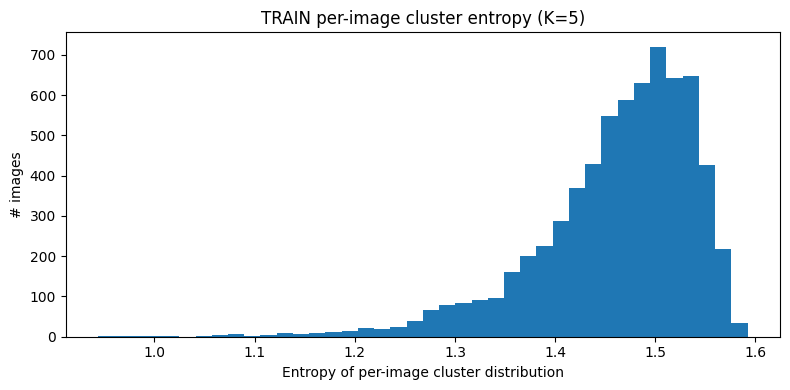

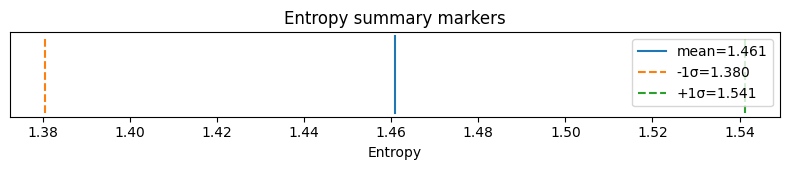

In [14]:
# Cell 12 — Plot per-image entropy distribution + summary lines
def entropy(p: np.ndarray) -> float:
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p * np.log(p)).sum())

ents = np.array([entropy(p) for p in per_probs.values()], dtype=np.float64)

plt.figure(figsize=(8, 4))
plt.hist(ents, bins=40)
plt.xlabel("Entropy of per-image cluster distribution")
plt.ylabel("# images")
plt.title(f"{SPLIT.upper()} per-image cluster entropy (K={K_REGIONS})")
plt.tight_layout()
plt.show()

# show mean/std
mu, sigma = float(ents.mean()), float(ents.std())
plt.figure(figsize=(8, 1.8))
plt.plot([mu, mu], [0, 1], label=f"mean={mu:.3f}")
plt.plot([mu - sigma, mu - sigma], [0, 1], linestyle="--", label=f"-1σ={mu-sigma:.3f}")
plt.plot([mu + sigma, mu + sigma], [0, 1], linestyle="--", label=f"+1σ={mu+sigma:.3f}")
plt.yticks([])
plt.xlabel("Entropy")
plt.title("Entropy summary markers")
plt.legend()
plt.tight_layout()
plt.show()


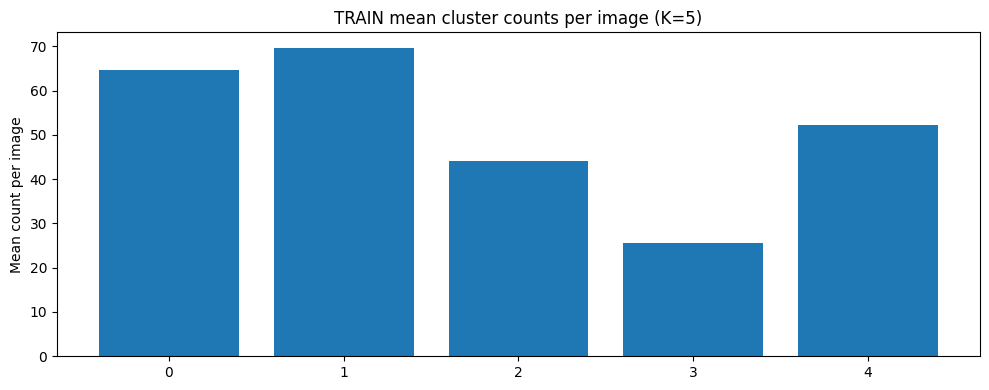

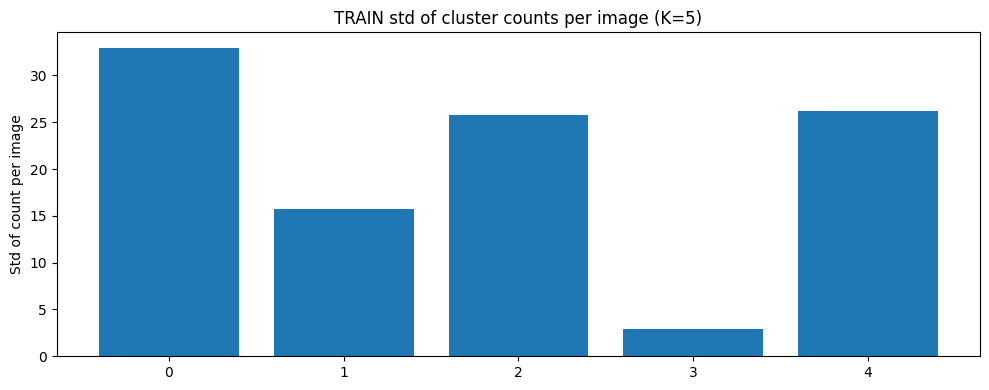

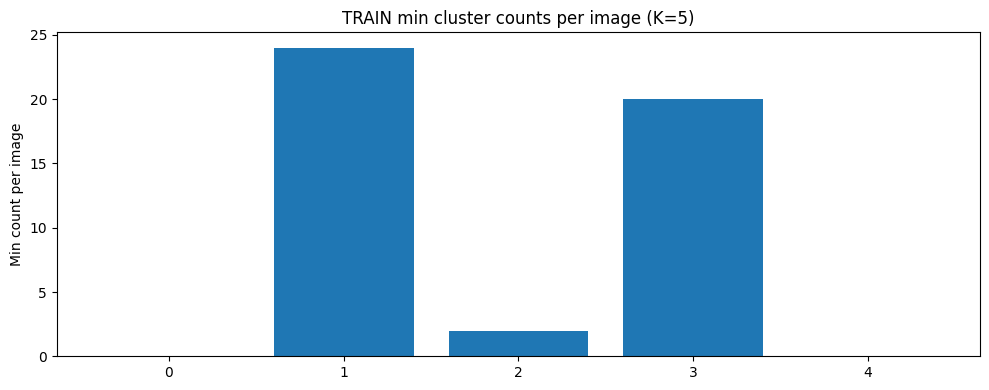

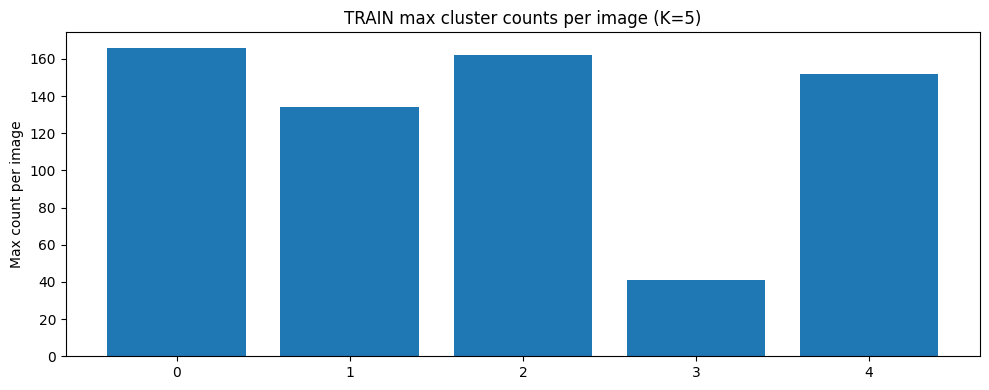

In [15]:
# Cell 13 — Plot per-image cluster count stats: mean/std/min/max across images
# Stack per-image counts into (N,K)
stems_list = list(per_counts.keys())
counts_mat = np.stack([per_counts[s] for s in stems_list], axis=0)  # (N,K)

mean_c = counts_mat.mean(axis=0)
std_c  = counts_mat.std(axis=0)
min_c  = counts_mat.min(axis=0)
max_c  = counts_mat.max(axis=0)

x = np.arange(K_REGIONS)

plt.figure(figsize=(10, 4))
plt.bar(x, mean_c)
plt.xticks(x)
plt.ylabel("Mean count per image")
plt.title(f"{SPLIT.upper()} mean cluster counts per image (K={K_REGIONS})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(x, std_c)
plt.xticks(x)
plt.ylabel("Std of count per image")
plt.title(f"{SPLIT.upper()} std of cluster counts per image (K={K_REGIONS})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(x, min_c)
plt.xticks(x)
plt.ylabel("Min count per image")
plt.title(f"{SPLIT.upper()} min cluster counts per image (K={K_REGIONS})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(x, max_c)
plt.xticks(x)
plt.ylabel("Max count per image")
plt.title(f"{SPLIT.upper()} max cluster counts per image (K={K_REGIONS})")
plt.tight_layout()
plt.show()


# score 

In [16]:
# Cell 16 — Weight formulations (global + per-image) + utilities
import numpy as np
import matplotlib.pyplot as plt

# --- helpers ---
def normalize_sum1(w: np.ndarray) -> np.ndarray:
    w = np.asarray(w, dtype=np.float64)
    s = w.sum()
    return w / (s + 1e-12)

def normalize_mean1(w: np.ndarray) -> np.ndarray:
    w = np.asarray(w, dtype=np.float64)
    return w / (w.mean() + 1e-12)

def safe_pow(x: np.ndarray, p: float) -> np.ndarray:
    return np.power(np.maximum(x, 1e-12), p)

def clip_weights(w: np.ndarray, w_min: float = 0.1, w_max: float = 10.0) -> np.ndarray:
    return np.clip(w, w_min, w_max)

def compute_global_freq_from_probs(global_probs: np.ndarray) -> np.ndarray:
    # already sums to 1
    p = np.asarray(global_probs, dtype=np.float64)
    return np.clip(p, 1e-12, 1.0)

# --- weight recipes (per cluster) ---
def w_inv_freq(global_probs: np.ndarray, alpha: float = 1.0, eps: float = 1e-6) -> np.ndarray:
    """
    w_k = (p_k + eps)^(-alpha)
    alpha=1 is strong, alpha=0.5 softer
    """
    p = compute_global_freq_from_probs(global_probs)
    return safe_pow(p + eps, -alpha)

def w_sqrt_inv(global_probs: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Common gentle choice: w_k = 1 / sqrt(p_k + eps)"""
    p = compute_global_freq_from_probs(global_probs)
    return 1.0 / np.sqrt(p + eps)

def w_effective_num(global_counts: np.ndarray, beta: float = 0.999, eps: float = 1e-8) -> np.ndarray:
    """
    Effective number of samples (Cui et al. style):
      eff_k = (1 - beta^{n_k}) / (1 - beta)
      w_k ∝ 1 / (eff_k + eps)
    """
    n = np.asarray(global_counts, dtype=np.float64)
    eff = (1.0 - np.power(beta, n)) / (1.0 - beta + 1e-12)
    return 1.0 / (eff + eps)

def w_softmax_temp(global_probs: np.ndarray, temp: float = 1.0) -> np.ndarray:
    """
    Another smooth option:
      logits_k = -log(p_k)
      w = softmax(logits / temp)
    Gives positive weights that sum to 1 (before rescaling).
    """
    p = compute_global_freq_from_probs(global_probs)
    logits = -np.log(p)
    z = logits / max(temp, 1e-12)
    z = z - z.max()
    w = np.exp(z)
    return w / (w.sum() + 1e-12)

def w_tfidf_like(per_image_probs: Dict[str, np.ndarray], eps: float = 1e-12) -> np.ndarray:
    """
    "IDF" part: clusters that appear in fewer images get higher weight.
    df_k = fraction of images where p_k > 0
    idf_k = log(N / (df_k*N + eps)) = -log(df_k + eps)
    """
    keys = list(per_image_probs.keys())
    P = np.stack([per_image_probs[k] for k in keys], axis=0)  # (N,K)
    df = (P > 0).mean(axis=0)  # fraction of images using that cluster
    idf = -np.log(df + eps)
    return idf

# --- compute a dictionary of candidate weight vectors ---
W = {}
W["inv_freq_a1"]   = w_inv_freq(global_probs, alpha=1.0)
W["inv_freq_a05"]  = w_inv_freq(global_probs, alpha=0.5)
W["sqrt_inv"]      = w_sqrt_inv(global_probs)
W["effnum_b0999"]  = w_effective_num(global_counts, beta=0.999)
W["softmax_t1"]    = w_softmax_temp(global_probs, temp=1.0)
W["softmax_t05"]   = w_softmax_temp(global_probs, temp=0.5)
W["tfidf_idf"]     = w_tfidf_like(per_probs)

# Post-process: normalize mean=1 and clip (so training doesn't explode)
W_proc = {}
for name, w in W.items():
    w2 = normalize_mean1(w)
    w2 = clip_weights(w2, w_min=0.25, w_max=4.0)
    W_proc[name] = w2

print("Available weight schemes:", list(W_proc.keys()))
for k, v in W_proc.items():
    print(k, "min", float(v.min()), "max", float(v.max()), "mean", float(v.mean()))


Available weight schemes: ['inv_freq_a1', 'inv_freq_a05', 'sqrt_inv', 'effnum_b0999', 'softmax_t1', 'softmax_t05', 'tfidf_idf']
inv_freq_a1 min 0.6475429397603798 max 1.76349801796913 mean 0.9999999999998236
inv_freq_a05 min 0.8192639768394615 max 1.3520011497893696 mean 0.9999999999995728
sqrt_inv min 0.8192639768394615 max 1.3520011497893696 mean 0.9999999999995728
effnum_b0999 min 0.999999999 max 0.999999999 mean 0.9999999990000001
softmax_t1 min 0.6475410442631415 max 1.7635040230688428 mean 0.9999999999950001
softmax_t05 min 0.3604161517243705 max 2.6731452169763665 mean 0.9999999999949999
tfidf_idf min 0.25 max 4.0 mean 1.0


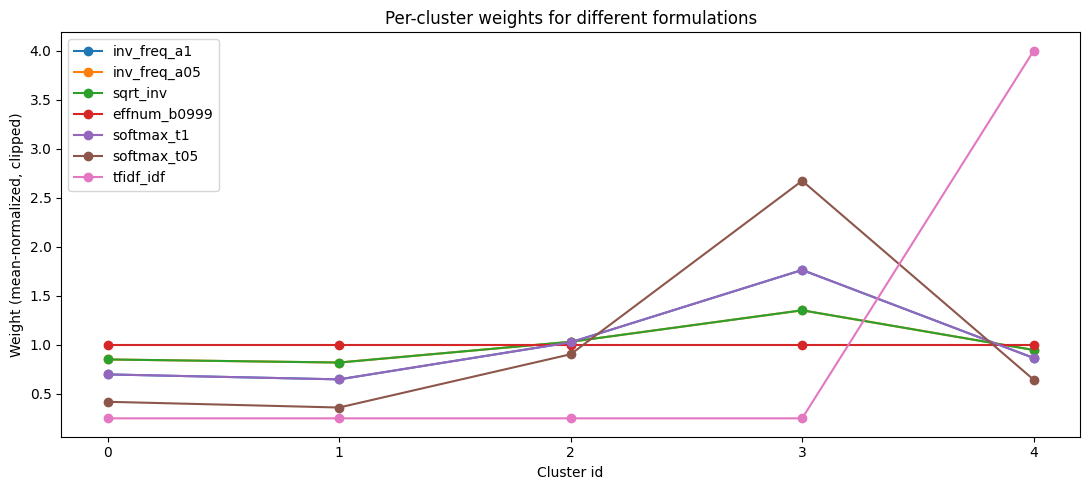

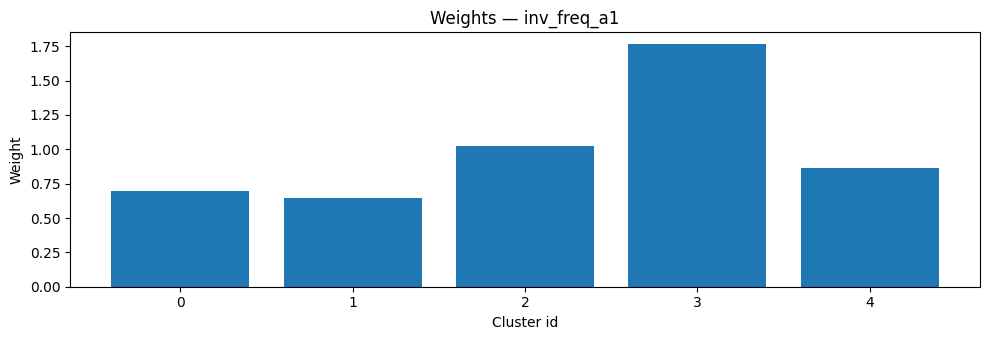

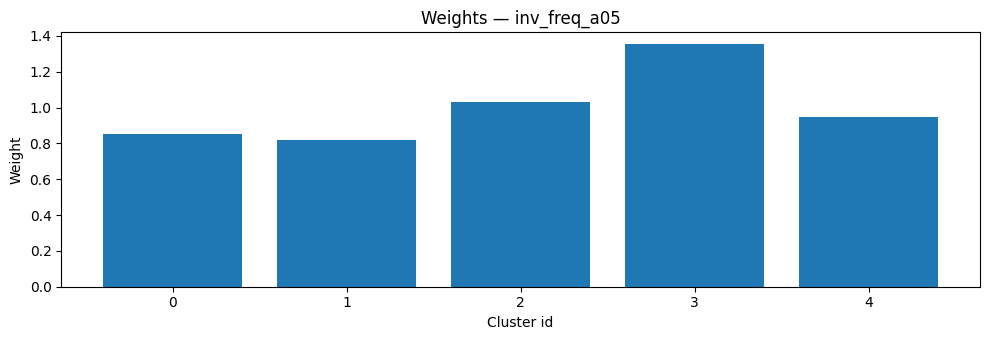

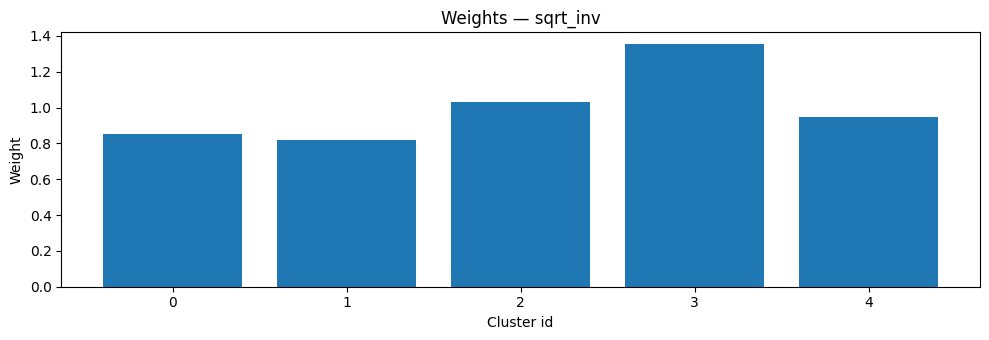

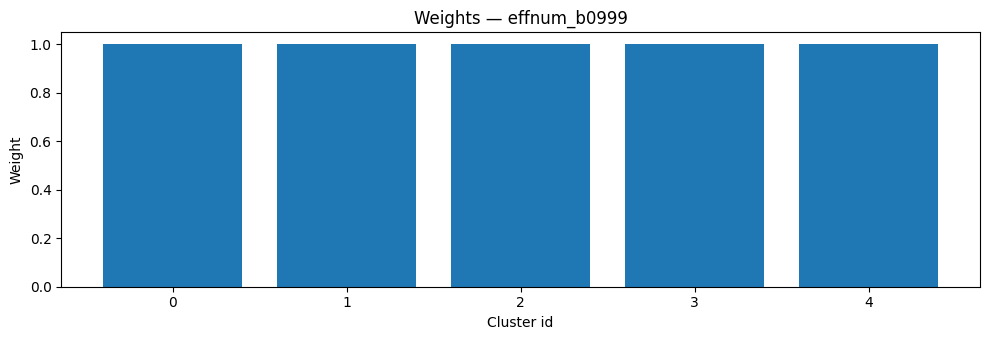

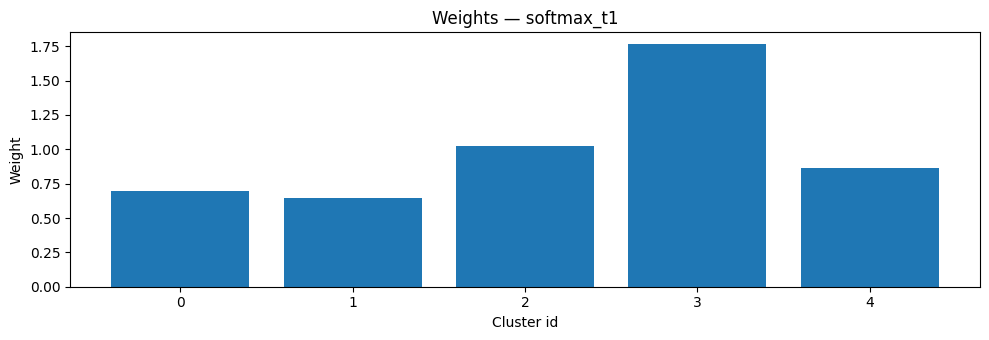

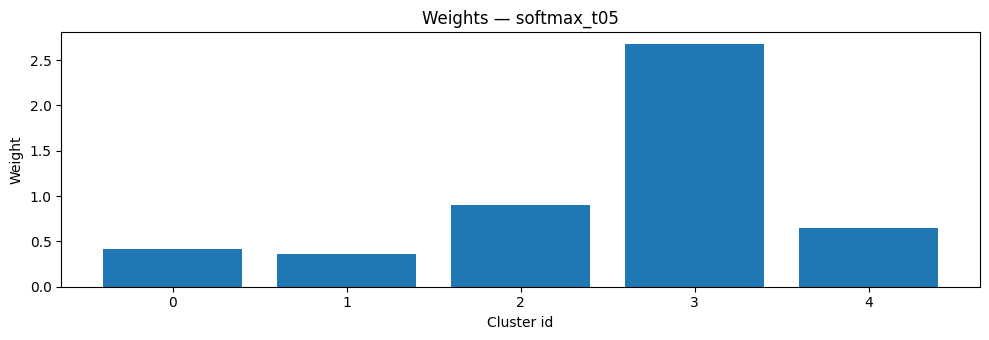

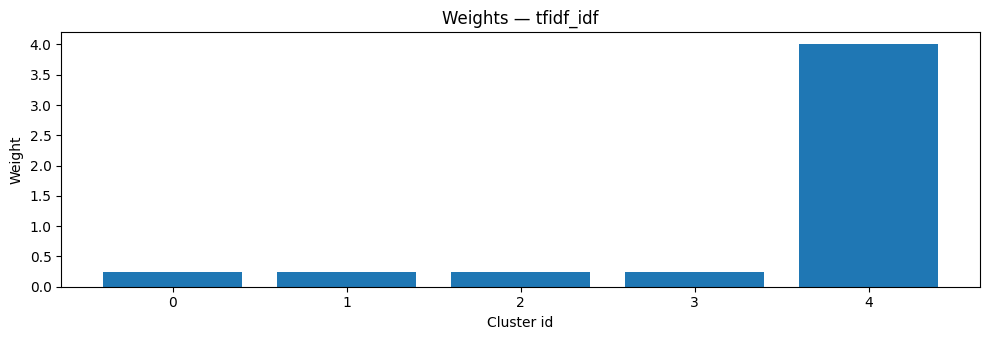

In [17]:
# Cell 17 — Plot weight vectors (per cluster) for all schemes
x = np.arange(K_REGIONS)

plt.figure(figsize=(11, 5))
for name, w in W_proc.items():
    plt.plot(x, w, marker="o", label=name)

plt.xticks(x)
plt.xlabel("Cluster id")
plt.ylabel("Weight (mean-normalized, clipped)")
plt.title("Per-cluster weights for different formulations")
plt.legend()
plt.tight_layout()
plt.show()

# Also show each scheme as a bar plot (one figure per scheme)
for name, w in W_proc.items():
    plt.figure(figsize=(10, 3.5))
    plt.bar(x, w)
    plt.xticks(x)
    plt.xlabel("Cluster id")
    plt.ylabel("Weight")
    plt.title(f"Weights — {name}")
    plt.tight_layout()
    plt.show()


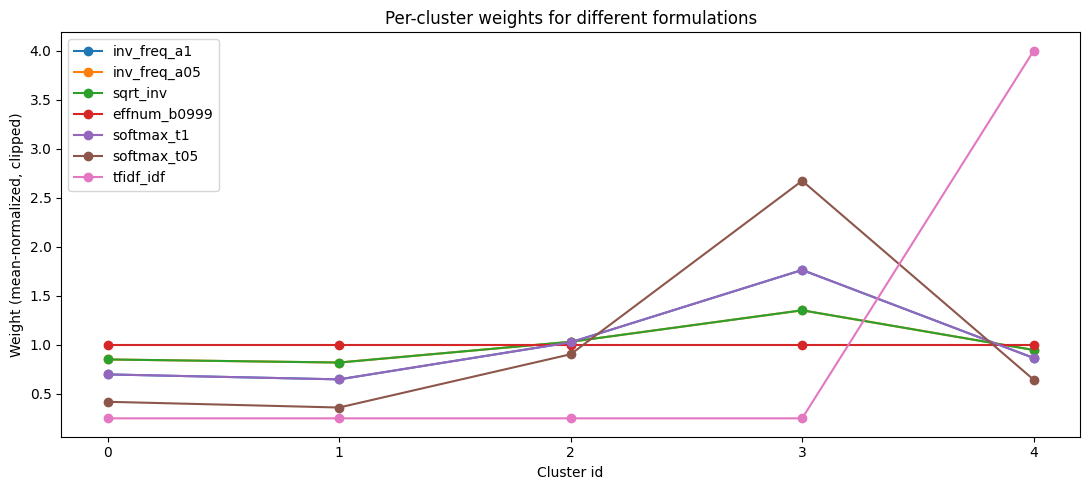

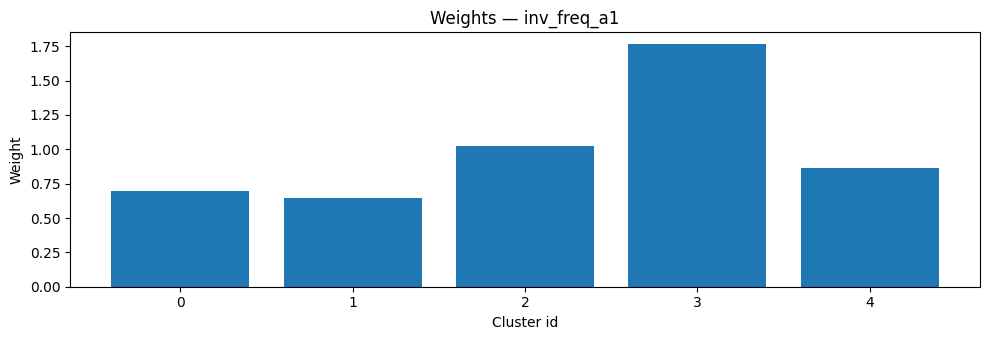

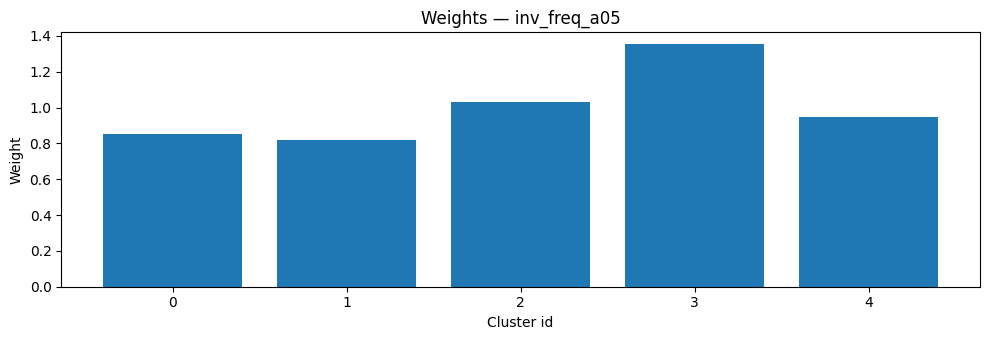

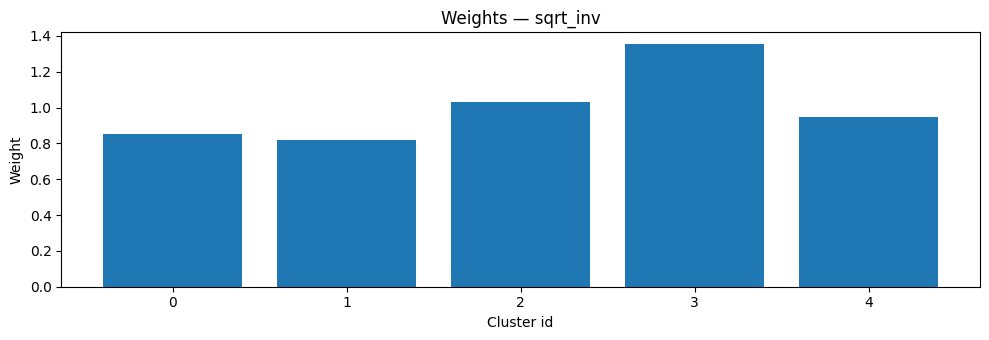

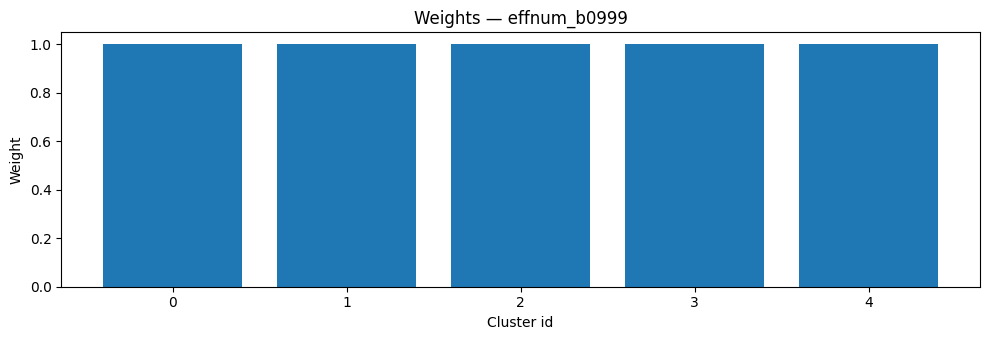

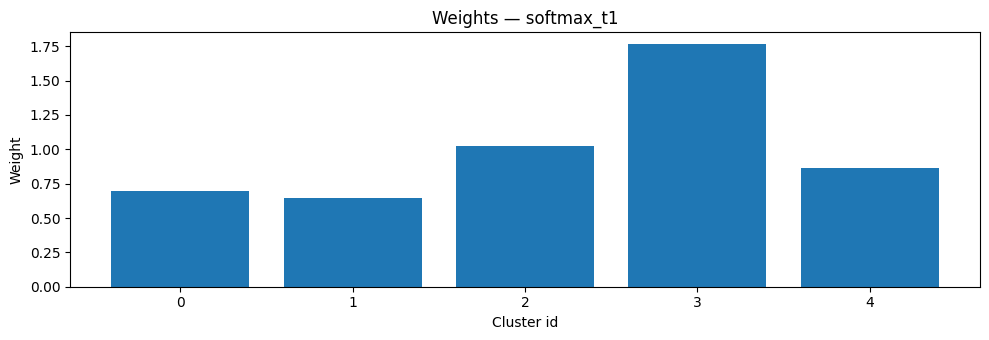

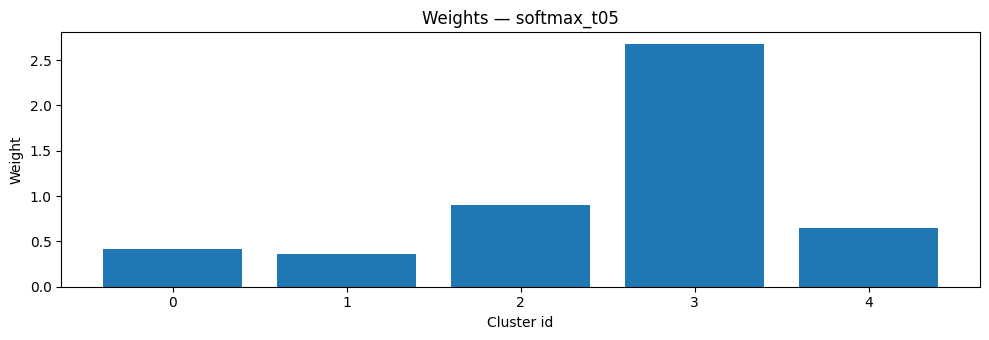

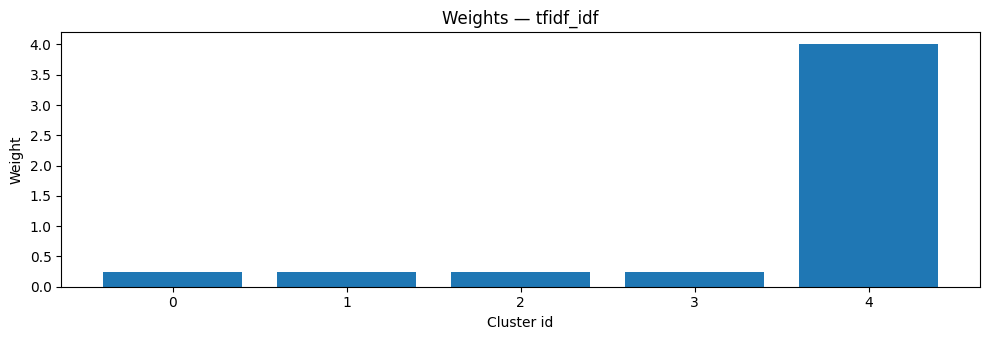

In [18]:
# Cell 17 — Plot weight vectors (per cluster) for all schemes
x = np.arange(K_REGIONS)

plt.figure(figsize=(11, 5))
for name, w in W_proc.items():
    plt.plot(x, w, marker="o", label=name)

plt.xticks(x)
plt.xlabel("Cluster id")
plt.ylabel("Weight (mean-normalized, clipped)")
plt.title("Per-cluster weights for different formulations")
plt.legend()
plt.tight_layout()
plt.show()

# Also show each scheme as a bar plot (one figure per scheme)
for name, w in W_proc.items():
    plt.figure(figsize=(10, 3.5))
    plt.bar(x, w)
    plt.xticks(x)
    plt.xlabel("Cluster id")
    plt.ylabel("Weight")
    plt.title(f"Weights — {name}")
    plt.tight_layout()
    plt.show()


In [19]:
# Cell 18 — Define S(x): per-image weight map from cluster labels
# S(x) is a (Gh,Gw) grid weight map produced by mapping each label -> w[label]

def weight_map_from_labels(lbl_hw: np.ndarray, w_k: np.ndarray, k_regions: int) -> np.ndarray:
    lbl = lbl_hw.astype(np.int64)

    # fix range 1..K -> 0..K-1 if needed
    if lbl.min() == 1 and lbl.max() == k_regions:
        lbl = lbl - 1
    lbl = np.clip(lbl, 0, k_regions - 1)

    return w_k[lbl]  # (Gh,Gw)

# Quick test on one item
idx = 0
item = ds[idx]
lbl = item["cluster_lbl"].numpy()
w_k = W_proc["sqrt_inv"]  # pick one

S = weight_map_from_labels(lbl, w_k, K_REGIONS)
print("S(x) shape:", S.shape, "min", float(S.min()), "max", float(S.max()))


S(x) shape: (16, 16) min 0.8192639768394615 max 1.3520011497893696


/tmp/ipykernel_453667/1546294290.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_clusters = plt.cm.get_cmap("tab20", K_REGIONS)


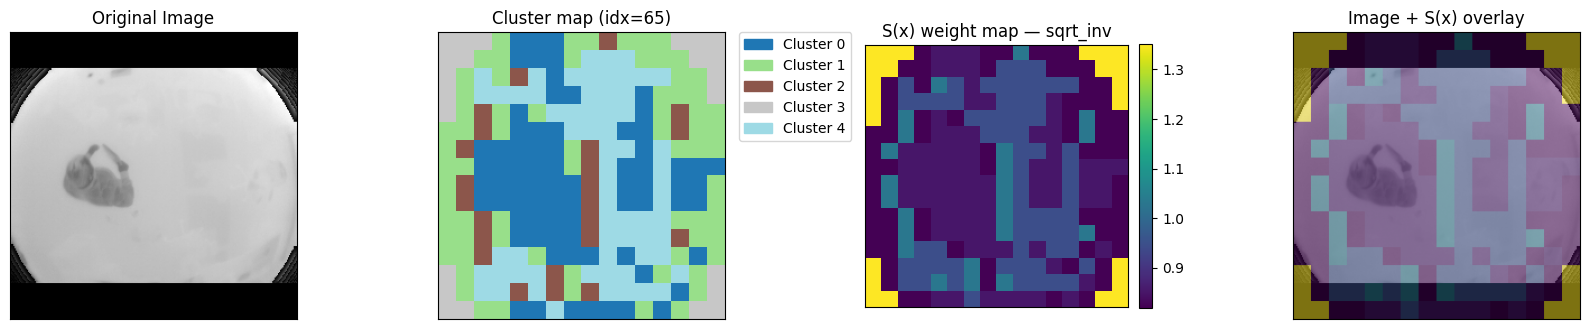

In [20]:
# Modified Cell 19 — show original image + cluster legend

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import torch
import torch.nn.functional as F

def show_Sx(ds, idx: int, scheme: str, overlay_on_image: bool = True):
    item = ds[idx]
    lbl = item["cluster_lbl"].numpy()

    # fix possible 1..K indexing
    if lbl.min() == 1 and lbl.max() == K_REGIONS:
        lbl = lbl - 1
    lbl = np.clip(lbl, 0, K_REGIONS - 1)

    w_k = W_proc[scheme]
    S = weight_map_from_labels(lbl, w_k, K_REGIONS)

    # --- discrete colormap for clusters ---
    cmap_clusters = plt.cm.get_cmap("tab20", K_REGIONS)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, K_REGIONS + 0.5, 1), K_REGIONS)

    plt.figure(figsize=(16, 4))

    # 1) Original image
    ax0 = plt.subplot(1, 4, 1)
    if "image" in item:
        img = item["image"].squeeze(0).numpy()
        ax0.imshow(img, cmap="gray")
        ax0.set_title("Original Image")
    else:
        ax0.text(0.5, 0.5, "No image loaded", ha="center")
    ax0.set_xticks([]); ax0.set_yticks([])

    # 2) Cluster map with legend
    ax1 = plt.subplot(1, 4, 2)
    im1 = ax1.imshow(lbl, cmap=cmap_clusters, norm=norm, interpolation="nearest")
    ax1.set_title(f"Cluster map (idx={idx})")
    ax1.set_xticks([]); ax1.set_yticks([])

    # Create legend
    unique_clusters = np.unique(lbl)
    patches = [
        mpatches.Patch(
            color=cmap_clusters(c),
            label=f"Cluster {c}"
        )
        for c in unique_clusters
    ]
    ax1.legend(
        handles=patches,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.
    )

    # 3) Weight map S(x)
    ax2 = plt.subplot(1, 4, 3)
    im2 = ax2.imshow(S, interpolation="nearest")
    ax2.set_title(f"S(x) weight map — {scheme}")
    ax2.set_xticks([]); ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # 4) Overlay on image
    ax3 = plt.subplot(1, 4, 4)
    if overlay_on_image and ("image" in item):
        img = item["image"].squeeze(0).numpy()
        ax3.imshow(img, cmap="gray")

        H, Wimg = img.shape
        S_up = torch.tensor(S)[None, None, ...].float()
        S_up = F.interpolate(S_up, size=(H, Wimg), mode="nearest").squeeze().numpy()

        ax3.imshow(S_up, alpha=0.5)
        ax3.set_title("Image + S(x) overlay")
    else:
        ax3.imshow(S, interpolation="nearest")
        ax3.set_title("S(x)")

    ax3.set_xticks([]); ax3.set_yticks([])

    plt.tight_layout()
    plt.show()


# Example
show_Sx(ds, idx=65, scheme="sqrt_inv")


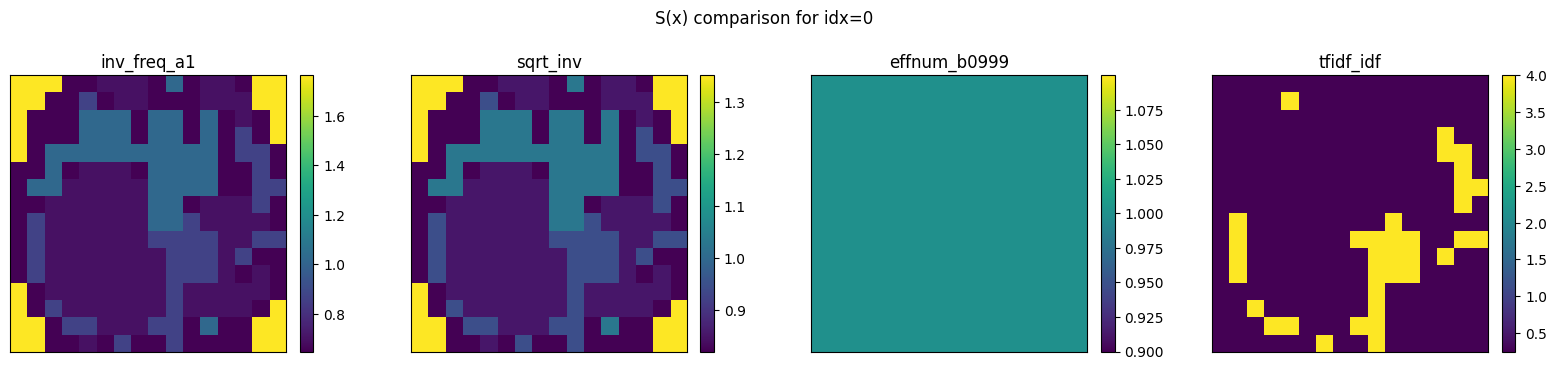

In [21]:
# Cell 20 — Compare multiple schemes on the SAME sample
def compare_schemes_on_one(ds, idx: int, schemes: List[str]):
    item = ds[idx]
    lbl = item["cluster_lbl"].numpy()

    n = len(schemes)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * 4.0, rows * 3.5))
    for i, scheme in enumerate(schemes):
        w_k = W_proc[scheme]
        S = weight_map_from_labels(lbl, w_k, K_REGIONS)

        ax = plt.subplot(rows, cols, i + 1)
        im = ax.imshow(S, interpolation="nearest")
        ax.set_title(scheme)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"S(x) comparison for idx={idx}", y=1.02)
    plt.tight_layout()
    plt.show()

compare_schemes_on_one(ds, idx=0, schemes=["inv_freq_a1", "sqrt_inv", "effnum_b0999", "tfidf_idf"])


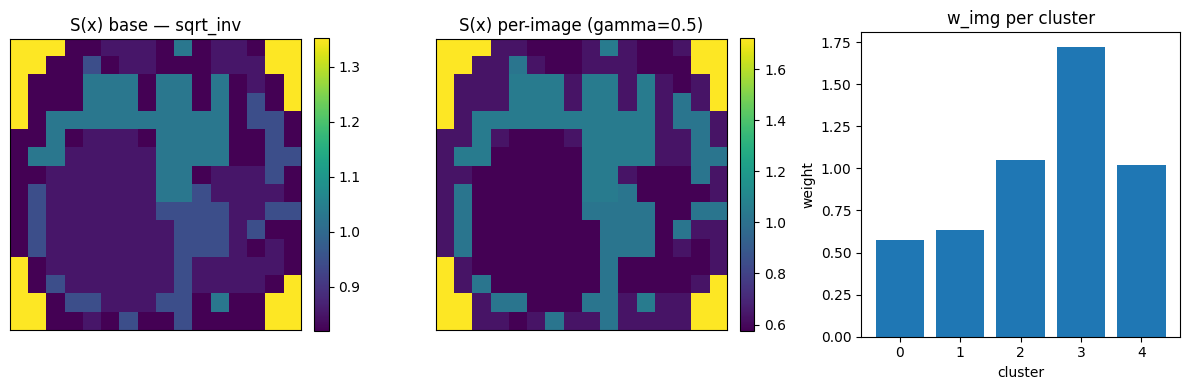

In [22]:
# Cell 21 — More complex S(x): per-image "rarity" weighting (global + image composition)
# Idea: if an image is dominated by common clusters, upweight the rare clusters present more aggressively.
# One simple form:
#   w_k^(img) = base_w_k * ( (p_img_k + eps)^(-gamma) )
# This makes weights depend on the per-image histogram too.

def per_image_weights(base_w: np.ndarray, p_img: np.ndarray, gamma: float = 0.5, eps: float = 1e-8):
    # base_w: (K,), p_img: (K,) sums to 1
    w = base_w * safe_pow(p_img + eps, -gamma)
    w = normalize_mean1(w)
    w = clip_weights(w, 0.25, 4.0)
    return w

def show_Sx_per_image_variant(ds, idx: int, base_scheme: str = "sqrt_inv", gamma: float = 0.5):
    item = ds[idx]
    stem = item["stem"]
    lbl = item["cluster_lbl"].numpy()

    base_w = W_proc[base_scheme]
    p_img = per_probs[stem]  # (K,)
    w_img = per_image_weights(base_w, p_img, gamma=gamma)

    S_base = weight_map_from_labels(lbl, base_w, K_REGIONS)
    S_img  = weight_map_from_labels(lbl, w_img,  K_REGIONS)

    plt.figure(figsize=(12, 4))
    ax1 = plt.subplot(1, 3, 1)
    im1 = ax1.imshow(S_base, interpolation="nearest")
    ax1.set_title(f"S(x) base — {base_scheme}")
    ax1.set_xticks([]); ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = plt.subplot(1, 3, 2)
    im2 = ax2.imshow(S_img, interpolation="nearest")
    ax2.set_title(f"S(x) per-image (gamma={gamma})")
    ax2.set_xticks([]); ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    ax3 = plt.subplot(1, 3, 3)
    ax3.bar(np.arange(K_REGIONS), w_img)
    ax3.set_title("w_img per cluster")
    ax3.set_xticks(np.arange(K_REGIONS))
    ax3.set_xlabel("cluster"); ax3.set_ylabel("weight")

    plt.tight_layout()
    plt.show()

show_Sx_per_image_variant(ds, idx=0, base_scheme="sqrt_inv", gamma=0.5)


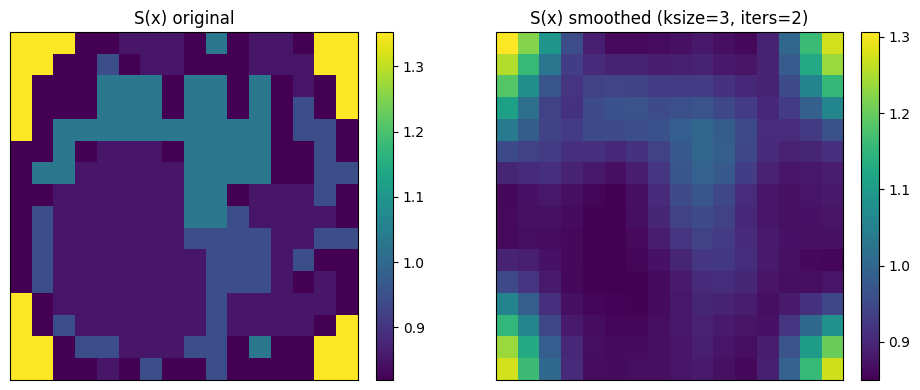

In [23]:
# Cell 22 — Another complex S(x): spatial smoothing of weights (optional)
# Sometimes you want S(x) to be smoother (less blocky) to avoid harsh gradient discontinuities.
# We'll smooth S on the grid with a small averaging kernel (not changing labels, only weights).

import torch
import torch.nn.functional as F

def smooth_weight_map(S_hw: np.ndarray, ksize: int = 3, iters: int = 1) -> np.ndarray:
    S = torch.tensor(S_hw, dtype=torch.float32)[None, None, ...]  # (1,1,H,W)
    kernel = torch.ones((1, 1, ksize, ksize), dtype=torch.float32)
    kernel = kernel / kernel.numel()
    pad = ksize // 2
    for _ in range(iters):
        S = F.conv2d(F.pad(S, (pad, pad, pad, pad), mode="replicate"), kernel)
    return S.squeeze().numpy()

def show_smoothed_Sx(ds, idx: int, scheme: str = "sqrt_inv", ksize: int = 3, iters: int = 2):
    item = ds[idx]
    lbl = item["cluster_lbl"].numpy()
    w_k = W_proc[scheme]
    S = weight_map_from_labels(lbl, w_k, K_REGIONS)
    S_sm = smooth_weight_map(S, ksize=ksize, iters=iters)

    plt.figure(figsize=(10, 4))
    ax1 = plt.subplot(1, 2, 1)
    im1 = ax1.imshow(S, interpolation="nearest")
    ax1.set_title("S(x) original")
    ax1.set_xticks([]); ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    ax2 = plt.subplot(1, 2, 2)
    im2 = ax2.imshow(S_sm, interpolation="nearest")
    ax2.set_title(f"S(x) smoothed (ksize={ksize}, iters={iters})")
    ax2.set_xticks([]); ax2.set_yticks([])
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

show_smoothed_Sx(ds, idx=0, scheme="sqrt_inv", ksize=3, iters=2)


In [24]:
# Cell 23 — How you'd use S(x) in an FM loss (demo only, no model needed)
# Suppose:
#   pred_v, target_v are tensors (B, C, h, w) in latent space
# and cluster_lbl is (B, Gh, Gw) e.g. 16x16 that aligns to latent grid if latent is also 16x16,
# or you upsample cluster_lbl to match (h,w).
#
# This cell shows how to build S(x) for a batch and apply it.

def make_S_batch(cluster_lbl_bhw: torch.Tensor, scheme: str, out_hw: Tuple[int, int]) -> torch.Tensor:
    """
    cluster_lbl_bhw: (B,Gh,Gw) int64
    out_hw: (h,w) for latent
    returns S: (B,1,h,w) float32
    """
    w_k = torch.tensor(W_proc[scheme], dtype=torch.float32)  # (K,)
    lbl = cluster_lbl_bhw.clone()

    # fix label range
    if int(lbl.min()) == 1 and int(lbl.max()) == K_REGIONS:
        lbl = lbl - 1
    lbl = torch.clamp(lbl, 0, K_REGIONS - 1)

    # map labels -> weights on grid
    S = w_k[lbl]  # (B,Gh,Gw)
    S = S[:, None, ...]  # (B,1,Gh,Gw)

    # upsample to latent resolution if needed
    if (S.shape[-2], S.shape[-1]) != out_hw:
        S = F.interpolate(S, size=out_hw, mode="nearest")

    return S

# Demo shapes
B, C, h, w = 4, 4, 16, 16
cluster_lbl = torch.randint(0, K_REGIONS, (B, 16, 16))

S = make_S_batch(cluster_lbl, scheme="sqrt_inv", out_hw=(h, w))
print("S:", S.shape, "min", float(S.min()), "max", float(S.max()))

# Example weighted MSE in latent space:
pred_v = torch.randn(B, C, h, w)
tgt_v  = torch.randn(B, C, h, w)

loss_unweighted = ((pred_v - tgt_v) ** 2).mean()
loss_weighted   = (S * (pred_v - tgt_v) ** 2).mean()  # broadcasting over C

print("loss_unweighted:", float(loss_unweighted))
print("loss_weighted  :", float(loss_weighted))


S: torch.Size([4, 1, 16, 16]) min 0.8192639946937561 max 1.3520011901855469
loss_unweighted: 1.9787240028381348
loss_weighted  : 1.9743506908416748
